# Evaluation — Part 1: phase-picking metrics

Compares stored baseline and fine-tuned inference records using the shared picking protocol and writes core metric tables and figures.


## 1. Environment and configuration

In [1]:
import sys
REPO = r"M:\Github\TFM_SeismicPhasePicker_ColombianAndesRegion"
sys.path.insert(0, REPO + r"\src\training")     # training_utils
sys.path.insert(0, REPO + r"\src\evaluation")   # evaluation_utils

import training_utils as tu
import evaluation_utils as eu

IMAGES_DIR = tu.REPO / "data" / "processed" / "images" / "evaluation"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# --- operating point --------------------------------------------------------
THR   = 0.30      # decision threshold, common to the four architectures
TOL_S = 0.50      # matching tolerance between a peak and the reference arrival

# Handling windows without a reference pick for the current phase:
#   "negative" -> their peaks count as false positives (original criterion)
#   "ignore"   -> those windows contribute neither TP nor FP for that phase
# Part 2 compares both criteria side by side.
UNLABELED = "negative"

TAGS = ["phasenet_all", "eqtransformer_all", "eqcct_all", "gpd_all"]

print(f"THR={THR}  TOL={TOL_S}s  unlabeled={UNLABELED}")

THR=0.3  TOL=0.5s  unlabeled=negative


## 2. Loading the records

In [2]:
payloads = eu.load_all(TAGS)

r0 = next(iter(payloads.values()))["baseline"]
n_eq    = sum(1 for x in r0 if x["category"] == "earthquake")
n_noise = sum(1 for x in r0 if x["category"] == "noise")
n_p     = sum(1 for x in r0 if x["true"]["P"] is not None)
n_s     = sum(1 for x in r0 if x["true"]["S"] is not None)
print(f"\ntest: {len(r0)} windows ({n_eq} earthquake, {n_noise} noise)")
print(f"reference arrivals: {n_p} P, {n_s} S")

  PhaseNet       tag=phasenet_all       15566 windows
  EQTransformer  tag=eqtransformer_all  15566 windows
  EQCCT          tag=eqcct_all          15566 windows
  GPD            tag=gpd_all            15566 windows

test: 15566 windows (7783 earthquake, 7783 noise)
reference arrivals: 7179 P, 2792 S


## 3. Comparison table

`detail` reports each architecture, version, and phase. `improvement` expresses the change after fine-tuning, with positive values indicating improvement for the selected metric.

In [3]:
detail, improvement = eu.summary_table(payloads, thr=THR, tol_s=TOL_S,
                                       unlabeled=UNLABELED)

COLS = ["architecture", "model", "TP", "FP", "FN",
        "recall", "precision", "f2", "mae_ms", "medae_ms", "bias_ms"]

for ph in ("P", "S"):
    print(f"\n{'='*96}\nPHASE {ph}\n{'='*96}")
    print(detail[detail.phase == ph][COLS].round(3).to_string(index=False))


PHASE P
 architecture     model   TP   FP   FN  recall  precision    f2  mae_ms  medae_ms  bias_ms
     PhaseNet  baseline 7132 2156   47   0.993      0.768 0.938  37.942      30.0    -20.0
     PhaseNet finetuned 7156  296   23   0.997      0.960 0.989  29.382      20.0      0.0
EQTransformer  baseline 6958 1734  221   0.969      0.801 0.930  43.915      30.0      0.0
EQTransformer finetuned 7051 1118  128   0.982      0.863 0.956  55.974      40.0    -10.0
        EQCCT  baseline 1857 2514 5322   0.259      0.425 0.281  36.182      30.0     20.0
        EQCCT finetuned 7077 1130  102   0.986      0.862 0.958  52.608      50.0    -10.0
          GPD  baseline 7158 2785   21   0.997      0.720 0.926  24.225       0.0      0.0
          GPD finetuned 7135  753   44   0.994      0.905 0.975  11.268       0.0      0.0

PHASE S
 architecture     model   TP   FP   FN  recall  precision    f2  mae_ms  medae_ms  bias_ms
     PhaseNet  baseline 1668   94 1124   0.597      0.947 0.645  55.330 

### 3.1. Improvement per architecture

In [4]:
for ph in ("P", "S"):
    sub = improvement[improvement.phase == ph]
    print(f"\n{'='*96}\nPHASE {ph} — baseline -> fine-tuned (% improvement)\n{'='*96}")
    for m in eu.CORE_METRICS:
        cols = ["architecture", f"{m}_baseline", f"{m}_finetuned", f"{m}_improvement_%"]
        t = sub[cols].round(3)
        t.columns = ["architecture", "baseline", "fine-tuned", "improvement %"]
        print(f"\n  {m}")
        print(t.to_string(index=False))


PHASE P — baseline -> fine-tuned (% improvement)

  recall
 architecture  baseline  fine-tuned  improvement %
     PhaseNet     0.993       0.997          0.337
EQTransformer     0.969       0.982          1.337
        EQCCT     0.259       0.986        281.099
          GPD     0.997       0.994         -0.321

  precision
 architecture  baseline  fine-tuned  improvement %
     PhaseNet     0.768       0.960         25.057
EQTransformer     0.801       0.863          7.824
        EQCCT     0.425       0.862        102.971
          GPD     0.720       0.905         25.647

  f2
 architecture  baseline  fine-tuned  improvement %
     PhaseNet     0.938       0.989          5.430
EQTransformer     0.930       0.956          2.773
        EQCCT     0.281       0.958        241.506
          GPD     0.926       0.975          5.275

  mae_ms
 architecture  baseline  fine-tuned  improvement %
     PhaseNet    37.942      29.382         22.559
EQTransformer    43.915      55.974        -

### 3.2. Summary table for the thesis

In [5]:
def thesis_table(improvement, phase):
    """Compact layout: one row per architecture, the six metrics and their improvement."""
    sub = improvement[improvement.phase == phase].set_index("architecture")
    rows = []
    for arch in sub.index:
        r = sub.loc[arch]
        row = {"Architecture": arch}
        for m, label, dec in [("recall", "Recall", 3), ("precision", "Precision", 3),
                              ("f2", "F2", 3), ("mae_ms", "MAE (ms)", 1),
                              ("medae_ms", "Median abs. err. (ms)", 1),
                              ("bias_ms", "Bias (ms)", 1)]:
            row[f"{label} baseline"]   = round(r[f"{m}_baseline"], dec)
            row[f"{label} fine-tuned"] = round(r[f"{m}_finetuned"], dec)
            row[f"{label} improv. %"]  = round(r[f"{m}_improvement_%"], 1)
        rows.append(row)
    return pd.DataFrame(rows)

table_P = thesis_table(improvement, "P")
table_S = thesis_table(improvement, "S")
display(table_P)
display(table_S)

,Architecture,Recall baseline,Recall fine-tuned,Recall improv. %,Precision baseline,Precision fine-tuned,Precision improv. %,F2 baseline,F2 fine-tuned,F2 improv. %,MAE (ms) baseline,MAE (ms) fine-tuned,MAE (ms) improv. %,Median abs. err. (ms) baseline,Median abs. err. (ms) fine-tuned,Median abs. err. (ms) improv. %,Bias (ms) baseline,Bias (ms) fine-tuned,Bias (ms) improv. %
0,PhaseNet,0.993,0.997,0.3,0.768,0.960,25.1,0.938,0.989,5.4,37.9,29.4,22.6,30.0,20.0,33.3,-20.0,0.0,100.0
1,EQTransformer,0.969,0.982,1.3,0.801,0.863,7.8,0.930,0.956,2.8,43.9,56.0,-27.5,30.0,40.0,-33.3,0.0,-10.0,NaN
2,EQCCT,0.259,0.986,281.1,0.425,0.862,103.0,0.281,0.958,241.5,36.2,52.6,-45.4,30.0,50.0,-66.7,20.0,-10.0,50.0
3,GPD,0.997,0.994,-0.3,0.720,0.905,25.6,0.926,0.975,5.3,24.2,11.3,53.5,0.0,0.0,NaN,0.0,0.0,NaN


,Architecture,Recall baseline,Recall fine-tuned,Recall improv. %,Precision baseline,Precision fine-tuned,Precision improv. %,F2 baseline,F2 fine-tuned,F2 improv. %,MAE (ms) baseline,MAE (ms) fine-tuned,MAE (ms) improv. %,Median abs. err. (ms) baseline,Median abs. err. (ms) fine-tuned,Median abs. err. (ms) improv. %,Bias (ms) baseline,Bias (ms) fine-tuned,Bias (ms) improv. %
0,PhaseNet,0.597,0.923,54.5,0.947,0.869,-8.2,0.645,0.912,41.3,55.3,53.2,3.9,40.0,30.0,25.0,-30.0,0.0,100.0
1,EQTransformer,0.333,0.847,154.6,0.926,0.873,-5.7,0.382,0.852,123.3,56.1,79.1,-41.1,40.0,50.0,-25.0,-20.0,20.0,-0.0
2,EQCCT,0.467,0.898,92.1,0.716,0.833,16.3,0.502,0.884,76.0,80.2,64.5,19.6,60.0,40.0,33.3,40.0,0.0,100.0
3,GPD,0.792,0.797,0.6,0.614,0.688,12.2,0.749,0.773,3.2,82.6,64.9,21.5,60.0,50.0,16.7,0.0,0.0,NaN


### 3.3. Saving

In [6]:
detail.to_csv(tu.RESULTS_DIR / "p1_detail.csv", index=False)
improvement.to_csv(tu.RESULTS_DIR / "p1_improvement.csv", index=False)
table_P.to_csv(tu.RESULTS_DIR / "p1_table_P.csv", index=False)
table_S.to_csv(tu.RESULTS_DIR / "p1_table_S.csv", index=False)
print("saved to", tu.RESULTS_DIR)

saved to M:\Github\TFM_SeismicPhasePicker_ColombianAndes\data\processed\eval_results


### 3.4. Common S-wave evaluation set

The S-wave tables use records whose pseudo-arrival falls in the window shared by all four architectures, together with the noise windows. This keeps the S comparison on one population. P-wave tables use the full test set; the earlier unfiltered S export remains diagnostic.

In [ ]:
# Use the architecture with the fewest S references to define the common set.
# Match records by trace name and retain all noise windows.
ARCHS = list(payloads.keys())
n_s_por_arch = {a: sum(1 for r in p["baseline"] if r["true"]["S"] is not None)
                for a, p in payloads.items()}
REF_ARCH = min(n_s_por_arch, key=n_s_por_arch.get)

COMMON_S = {r["trace_name"] for r in payloads[REF_ARCH]["baseline"]
            if r["true"]["S"] is not None}

print("referencias de S por arquitectura:", n_s_por_arch)
print(f"ventana restrictiva: {REF_ARCH}  ->  conjunto comun = {len(COMMON_S)} llegadas")


def restrict_to_common(recs):
    """Keep common S-reference windows and all noise windows."""
    return [r for r in recs
            if r["trace_name"] in COMMON_S
            or str(r.get("category", "")).lower() == "noise"]


payloads_s = {a: {key: restrict_to_common(p[key]) for _, key in eu.MODELS}
              for a, p in payloads.items()}

detail_s, improvement_s = eu.summary_table(payloads_s, thr=THR, tol_s=TOL_S,
                                           unlabeled=UNLABELED)
detail_s = detail_s[detail_s.phase == "S"].reset_index(drop=True)

COLS_S = ["architecture", "model", "TP", "FP", "FN",
          "recall", "precision", "f2", "mae_ms", "medae_ms", "bias_ms"]
print("\nPHASE S — conjunto comun (lo que publica la memoria)")
print(detail_s[COLS_S].round(3).to_string(index=False))

table_S_comun = thesis_table(improvement_s, "S")
display(table_S_comun)

detail_s.to_csv(tu.RESULTS_DIR / "p1_detail_S_comun.csv", index=False)
table_S_comun.to_csv(tu.RESULTS_DIR / "p1_table_S_comun.csv", index=False)
print("guardado:", tu.RESULTS_DIR / "p1_table_S_comun.csv")


In [ ]:
# Format the common-set rows for the results tables.
NOMBRE = {"baseline": "Preentrenado", "finetuned": "Ajustado"}
EOL = " " + chr(92) * 2

def _fila(arch, label, cols, fmt):
    r = detail_s[(detail_s.architecture == arch) & (detail_s.model == label)].iloc[0]
    vals = " & ".join(format(r[c], f) for c, f in zip(cols, fmt))
    return f"                & {NOMBRE[label]:12s} & {vals}{EOL}"

for titulo, cols, fmt in [
        ("tab:eval_fase_s", ["recall", "precision", "f2"], [".3f", ".3f", ".3f"]),
        ("tab:precision_temporal_s", ["mae_ms", "medae_ms", "bias_ms"],
         [".1f", ".0f", ".0f"])]:
    print(f"\n% ---------- {titulo} ----------")
    for arch in ARCHS:
        print(arch)
        for label, _ in eu.MODELS:
            print(_fila(arch, label, cols, fmt))

# Compare common-set and full-population counts.
comp = (detail[detail.phase == "S"]
        .set_index(["architecture", "model"])[["recall", "precision", "f2", "mae_ms"]]
        .join(detail_s.set_index(["architecture", "model"])[["recall", "precision", "f2", "mae_ms"]],
              lsuffix="_completa", rsuffix="_comun"))
print("\nPoblacion completa vs conjunto comun (onda S)")
print(comp.round(3).to_string())


## 4. Pick-level confusion matrix

Rows represent reference P, reference S, and noise. Each pseudo-arrival contributes one count; each noise window contributes one count, assigned to the strongest predicted phase when a peak is present.

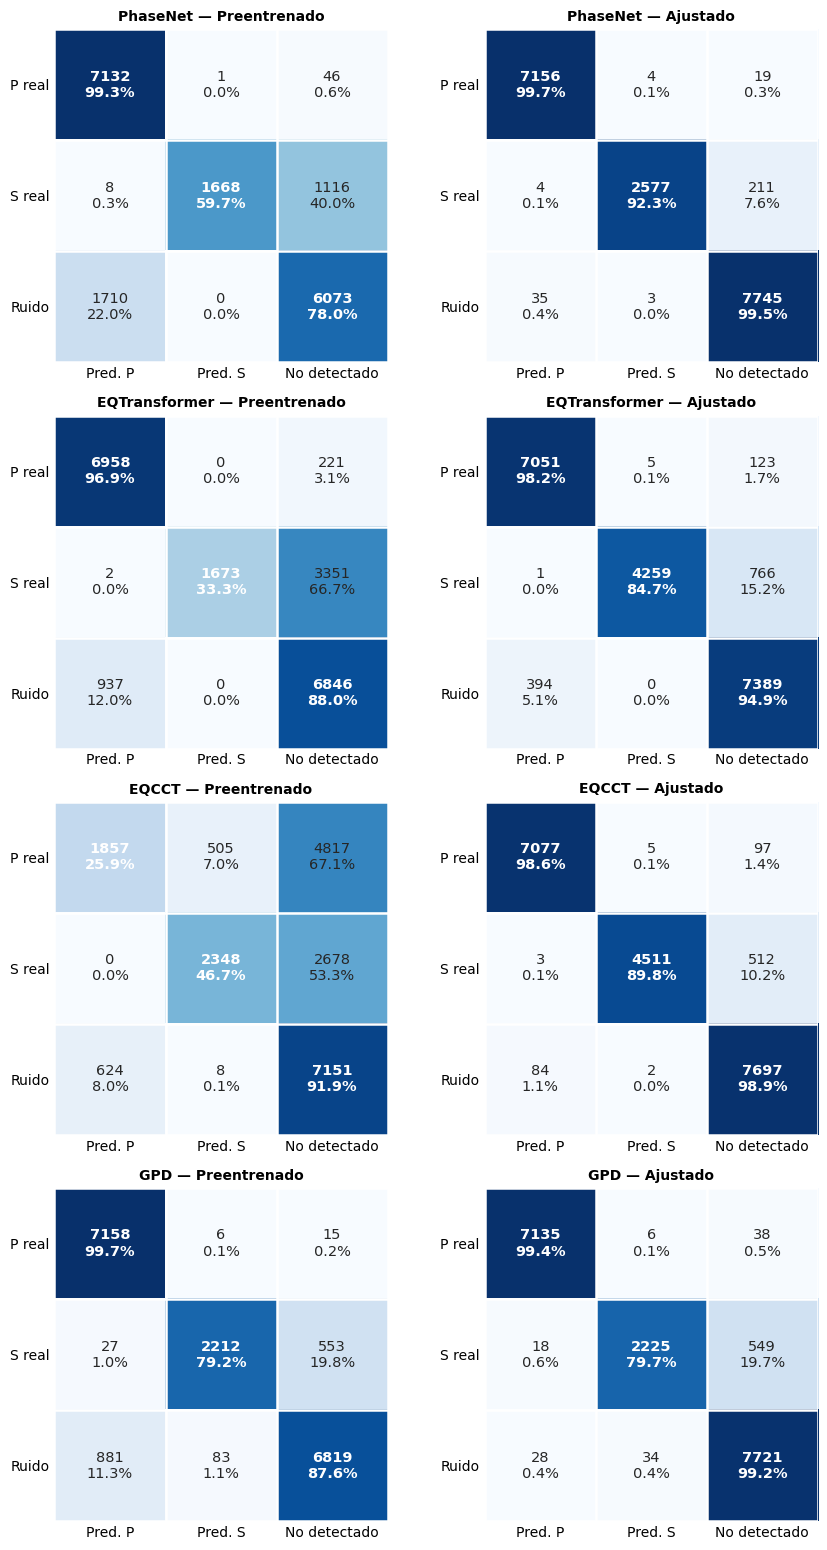

In [7]:
archs = list(payloads.keys())
confs = {}
fig, axes = plt.subplots(len(archs), 2, figsize=(9, 3.9 * len(archs)))
axes = np.atleast_2d(axes)

for i, arch in enumerate(archs):
    for j, (label, key) in enumerate(eu.MODELS):
        c = eu.confusion_pick_level(payloads[arch][key], thr=THR, tol_s=TOL_S)
        confs[(arch, label)] = c
        label_es = {"baseline": "Preentrenado", "finetuned": "Ajustado"}[label]
        eu.plot_confusion(axes[i][j], c, title=f"{arch} — {label_es}")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "p1_confusion.png", dpi=200, bbox_inches="tight")
plt.show()

### 4.1. Metrics derived from the matrix

In [8]:
rows = []
for (arch, label), c in confs.items():
    d = eu.confusion_derived(c)
    rows.append({"architecture": arch, "model": label,
                 "balanced accuracy": d["balanced_accuracy"],
                 "MCC": d["mcc"],
                 "P<->S confusion %": d["phase_confusion_%"]})
conf_df = pd.DataFrame(rows)
conf_df.to_csv(tu.RESULTS_DIR / "p1_confusion_derived.csv", index=False)
display(conf_df.round(3))

print("\nMCC (Matthews correlation coefficient) summarises the matrix in a single")
print("number that is robust to class imbalance. 'P<->S confusion %' is the share of")
print("true arrivals that were recovered but with the wrong phase.")

,architecture,model,balanced accuracy,MCC,P<->S confusion %
0,PhaseNet,baseline,0.790,0.741,0.102
1,PhaseNet,finetuned,0.972,0.975,0.082
2,EQTransformer,baseline,0.727,0.671,0.023
3,EQTransformer,finetuned,0.926,0.903,0.053
4,EQCCT,baseline,0.548,0.382,10.722
5,EQCCT,finetuned,0.957,0.947,0.069
6,GPD,baseline,0.888,0.859,0.351
7,GPD,finetuned,0.928,0.939,0.256



MCC (Matthews correlation coefficient) summarises the matrix in a single
number that is robust to class imbalance. 'P<->S confusion %' is the share of
true arrivals that were recovered but with the wrong phase.


## 5. Residual histogram

Residuals are predicted time minus pseudo-arrival time, measured for matched picks only. The distributions show signed offset and spread within that matched population.

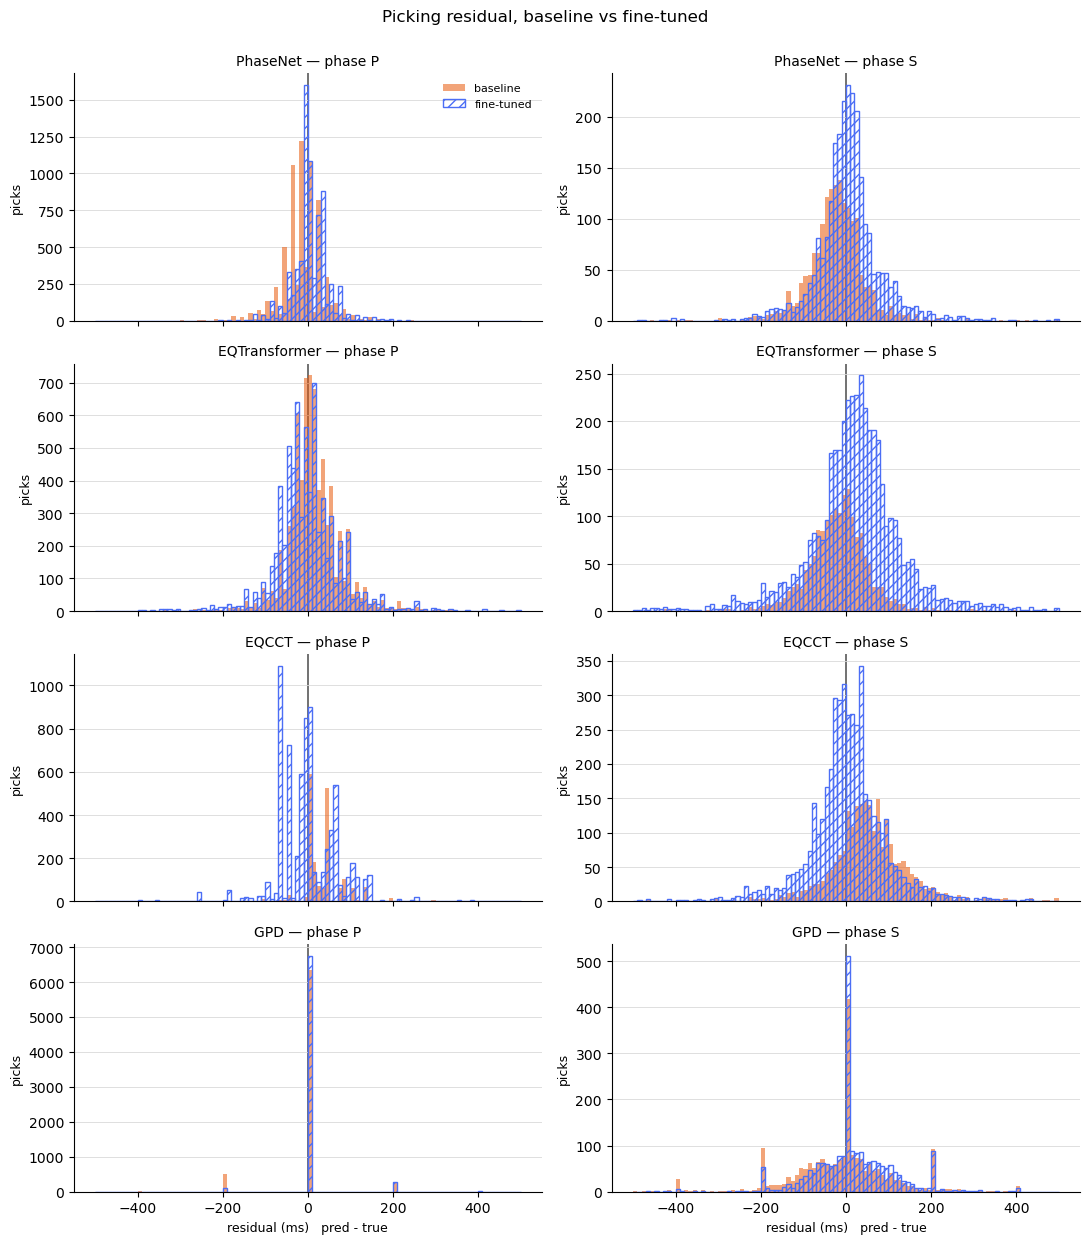

In [9]:
fig, axes = plt.subplots(len(archs), 2, figsize=(11, 3.1 * len(archs)),
                         sharex=True)
axes = np.atleast_2d(axes)

for i, arch in enumerate(archs):
    rb = eu.evaluate(payloads[arch]["baseline"],  THR, TOL_S, unlabeled=UNLABELED)
    rf = eu.evaluate(payloads[arch]["finetuned"], THR, TOL_S, unlabeled=UNLABELED)
    for j, ph in enumerate(("P", "S")):
        ax = axes[i][j]
        eu.plot_residuals(ax, rb[ph].residuals_ms, rf[ph].residuals_ms,
                          phase=ph, show_legend=(i == 0 and j == 0))
        ax.set_title(f"{arch} — phase {ph}", fontsize=10)
        if i < len(archs) - 1:
            ax.set_xlabel("")

fig.suptitle("Picking residual, baseline vs fine-tuned", fontsize=12, y=1.0)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "p1_residuals.png", dpi=160, bbox_inches="tight")
plt.show()

## 6. Alternative operating point

Select a phase-specific F2 threshold on the dev split and apply it to test. This complements the fixed threshold used for the main comparison.

In [10]:
THR_SWEEP = np.round(np.arange(0.05, 0.96, 0.05), 2)
rows = []

for arch, tag in zip(archs, TAGS):
    try:
        dev = tu.load_records(tag + "_dev")
    except FileNotFoundError:
        print(f"  {arch}: no dev records, skipped "
              f"(re-run collect with COLLECT_DEV=True)")
        continue
    for label, key in eu.MODELS:
        for ph in ("P", "S"):
            t_opt, f2_dev = eu.best_threshold(dev[key], ph, beta=2.0,
                                              thresholds=THR_SWEEP, tol_s=TOL_S,
                                              unlabeled=UNLABELED)
            r = eu.evaluate(payloads[arch][key], t_opt, TOL_S,
                            unlabeled=UNLABELED)[ph]
            rows.append({"architecture": arch, "model": label, "phase": ph,
                         "dev_threshold": t_opt, "F2_dev": f2_dev,
                         "recall_test": r.recall, "precision_test": r.precision,
                         "F2_test": r.f2})

if rows:
    op = pd.DataFrame(rows)
    op.to_csv(tu.RESULTS_DIR / "p1_operating_point.csv", index=False)
    for ph in ("P", "S"):
        print(f"\nPHASE {ph} — threshold chosen on dev, applied to test")
        print(op[op.phase == ph].round(3).to_string(index=False))


PHASE P — threshold chosen on dev, applied to test
 architecture     model phase  dev_threshold  F2_dev  recall_test  precision_test  F2_test
     PhaseNet  baseline     P           0.40   0.943        0.982           0.805    0.941
     PhaseNet finetuned     P           0.30   0.990        0.997           0.960    0.989
EQTransformer  baseline     P           0.35   0.935        0.958           0.833    0.930
EQTransformer finetuned     P           0.40   0.961        0.979           0.882    0.958
        EQCCT  baseline     P           0.05   0.373        0.402           0.304    0.377
        EQCCT finetuned     P           0.35   0.957        0.982           0.875    0.959
          GPD  baseline     P           0.55   0.967        0.984           0.904    0.967
          GPD finetuned     P           0.40   0.976        0.990           0.920    0.975

PHASE S — threshold chosen on dev, applied to test
 architecture     model phase  dev_threshold  F2_dev  recall_test  precision_

## 7. Interpreting the metrics

The references are consensus pseudo-labels built partly from the baseline architectures, so the scores measure agreement with those labels rather than accuracy against independent manual picks. Interpret P and S separately; Part 2 also separates real from synthetic noise.